##### Change to root for accessing data directory

In [18]:
import os
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks" and Path.exists(current_dir.parent / Path("data")):
    os.chdir(current_dir.parent)
    print(f"Current directory: {Path.cwd()}")
elif current_dir.name == "dt133g-thesis-project":
    print(f"Current directory: {Path.cwd()}")
else:
    print("Ensure data exists before running this notebook..")

Ensure data exists before running this notebook..


##### Imports and model names

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from statsmodels.distributions.empirical_distribution import ECDF

pretrained_models = {
    "cb": "microsoft/codebert-base",
    "gc": "microsoft/graphcodebert-base",
    "ux": "microsoft/unixcoder-base",
    "ct": "Salesforce/codet5p-770m",
    "ct_enc": "Salesforce/codet5p-770m-enc_only",
    "ds": "deepseek-ai/deepseek-coder-1.3b-base",
}

##### Plot configurations

In [20]:
sns.set_style("whitegrid")

TIER_ORDER = ["test", "tier_1", "tier_2", "tier_3", "tier_4"]

TITLE_MAP = {
    "conf_target": "Predicted Probability",
    "entropy": "Predictive Entropy",
    "epistemic_variance": "Epistemic Variance"
}

XLABEL_MAP = {
    "conf_target": "p(true)",
    "entropy": "H(p̄)",
    "epistemic_variance": "log10 (epistemic variance)"
}

METRICS = [
    "conf_target",
    "entropy",
    "epistemic_variance"
]

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

FIGURE_OUTDIR = Path("output/figures")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

def save_pub_figure(fig, name, dpi=300):
    """Save figure in PNG and PDF for thesis use."""
    png_path = FIGURE_OUTDIR / f"{name}.png"
    pdf_path = FIGURE_OUTDIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


## Model Comparison

##### Read CSVs into DataFrame

In [44]:
FILE_PATHS = []

for key, full_name in pretrained_models.items():
    if key == "ct_enc":
        continue
    DATASET_NAME = "droidcollection"

    FULL_MODEL_NAME = full_name
    MODEL_NAME = FULL_MODEL_NAME.split("/")[-1].rsplit("-")[0]

    FILE_PATHS.append(Path(f"data/fine_tune/models/{DATASET_NAME}/{FULL_MODEL_NAME}/eval_outputs/ood_metrics_{MODEL_NAME}.csv"))

df_all = pd.concat(pd.read_csv(file) for file in FILE_PATHS)
print(df_all.columns.values)
print("-"*66)
print(df_all['model_name'].unique())

<ArrowStringArray>
[        'model_name',         'model_type',               'tier',
         'snippet_id',         'true_label',         'pred_label',
         'is_correct',        'conf_target',            'entropy',
 'epistemic_variance']
Length: 10, dtype: str
------------------------------------------------------------------
<ArrowStringArray>
['codebert', 'graphcodebert', 'unixcoder', 'codet5p', 'deepseek']
Length: 5, dtype: str


##### Set model plot colors

In [45]:
ALL_MODELS = df_all["model_name"].unique()

palette = sns.color_palette("deep", n_colors=len(ALL_MODELS))
MODEL_COLORS = {model: color for model, color in zip(ALL_MODELS, palette)}

#### Generate Tables

In [47]:
from IPython.display import display

MODEL_DISPLAY_NAMES = {
    "codebert-base": "CodeBERT",
    "graphcodebert-base": "GraphCodeBERT",
    "unixcoder-base": "UniXcoder",
    "codet5p-770m": "CodeT5p",
    "deepseek-coder-1.3b-base": "DeepSeek",
}


def pretty_model_name(model_name):
    return MODEL_DISPLAY_NAMES.get(model_name, model_name.replace("-", " ").title())


def prepare_eval_slice(slice_df):
    slice_df = slice_df.copy()
    if "true_label" not in slice_df.columns or "pred_label" not in slice_df.columns:
        return pd.DataFrame()

    if "true_label" in slice_df.columns:
        slice_df = slice_df[slice_df["true_label"] != "true_label"].copy()

    slice_df = slice_df.dropna(subset=["true_label", "pred_label"])
    if slice_df.empty:
        return slice_df

    slice_df["true_label"] = slice_df["true_label"].astype(float).astype(int)
    slice_df["pred_label"] = slice_df["pred_label"].astype(float).astype(int)

    for metric in ["entropy", "epistemic_variance"]:
        if metric in slice_df.columns:
            slice_df[metric] = pd.to_numeric(slice_df[metric], errors="coerce")

    return slice_df


def build_comparison_tables(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    table_a_rows = []
    table_b_rows = []

    for model in models:
        test_df = prepare_eval_slice(df_source[(df_source["model_name"] == model) & (df_source["tier"] == "test")])
        if test_df.empty:
            continue

        y_true = test_df["true_label"].to_numpy(dtype=int)
        y_pred = test_df["pred_label"].to_numpy(dtype=int)

        baseline_accuracy = float(np.mean(y_true == y_pred))
        baseline_macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
        baseline_entropy = float(test_df["entropy"].dropna().mean()) if "entropy" in test_df.columns and not test_df["entropy"].dropna().empty else np.nan
        baseline_epistemic = float(test_df["epistemic_variance"].dropna().mean()) if "epistemic_variance" in test_df.columns and not test_df["epistemic_variance"].dropna().empty else np.nan

        table_a_rows.append({
            "Model": pretty_model_name(model),
            "Baseline Accuracy": baseline_accuracy,
            "Baseline Macro-F1": baseline_macro_f1,
            "Mean Entropy": baseline_entropy,
            "Mean Epistemic Var": baseline_epistemic,
        })

        tier4_df = prepare_eval_slice(df_source[(df_source["model_name"] == model) & (df_source["tier"] == "tier_4")])
        if tier4_df.empty:
            continue

        tier4_y_true = tier4_df["true_label"].to_numpy(dtype=int)
        tier4_y_pred = tier4_df["pred_label"].to_numpy(dtype=int)
        tier4_accuracy = float(np.mean(tier4_y_true == tier4_y_pred))
        tier4_macro_f1 = float(f1_score(tier4_y_true, tier4_y_pred, average="macro", zero_division=0))

        tier_deltas = []
        for tier in tiers:
            tier_df = prepare_eval_slice(df_source[(df_source["model_name"] == model) & (df_source["tier"] == tier)])
            if tier_df.empty:
                continue

            tier_y_true = tier_df["true_label"].to_numpy(dtype=int)
            tier_y_pred = tier_df["pred_label"].to_numpy(dtype=int)
            tier_accuracy = float(np.mean(tier_y_true == tier_y_pred))
            tier_macro_f1 = float(f1_score(tier_y_true, tier_y_pred, average="macro", zero_division=0))

            tier_entropy = float(tier_df["entropy"].dropna().mean()) if "entropy" in tier_df.columns and not tier_df["entropy"].dropna().empty else np.nan
            tier_epistemic = float(tier_df["epistemic_variance"].dropna().mean()) if "epistemic_variance" in tier_df.columns and not tier_df["epistemic_variance"].dropna().empty else np.nan

            tier_deltas.append({
                "tier": tier,
                "accuracy_delta": tier_accuracy - baseline_accuracy,
                "macro_f1_delta": tier_macro_f1 - baseline_macro_f1,
                "entropy_delta": tier_entropy - baseline_entropy if not np.isnan(tier_entropy) and not np.isnan(baseline_entropy) else np.nan,
                "epistemic_delta": tier_epistemic - baseline_epistemic if not np.isnan(tier_epistemic) and not np.isnan(baseline_epistemic) else np.nan,
            })

        tier_delta_df = pd.DataFrame(tier_deltas)
        table_b_rows.append({
            "Model": pretty_model_name(model),
            "Total Acc. Loss (T4)": tier4_accuracy - baseline_accuracy,
            "Total F1 Loss (T4)": tier4_macro_f1 - baseline_macro_f1,
            "Max Entropy Growth": tier_delta_df["entropy_delta"].max() if not tier_delta_df.empty else np.nan,
            "Max Epistemic Growth": tier_delta_df["epistemic_delta"].max() if not tier_delta_df.empty else np.nan,
        })

    table_a = pd.DataFrame(table_a_rows)
    table_b = pd.DataFrame(table_b_rows)

    if not table_a.empty:
        table_a = table_a.sort_values("Baseline Accuracy", ascending=False).reset_index(drop=True)
    if not table_b.empty:
        table_b = table_b.sort_values("Total Acc. Loss (T4)", ascending=True).reset_index(drop=True)

    return table_a, table_b


comparison_table_a, comparison_table_b = build_comparison_tables(df_all)

print(f"Table A: Absolute Baseline Performance ({DATASET_NAME.upper()})")
display(comparison_table_a.style.format({
    "Baseline Accuracy": "{:.3f}",
    "Baseline Macro-F1": "{:.3f}",
    "Mean Entropy": "{:.3f}",
    "Mean Epistemic Var": "{:.3f}",
}))

print(f"\nTable B: Tier-by-Tier Decay Summary ({DATASET_NAME.upper()})")
display(comparison_table_b.style.format({
    "Total Acc. Loss (T4)": "{:+.3f}",
    "Total F1 Loss (T4)": "{:+.3f}",
    "Max Entropy Growth": "{:+.3f}",
    "Max Epistemic Growth": "{:+.3f}",
}))


Table A: Absolute Baseline Performance (DROIDCOLLECTION)


,Model,Baseline Accuracy,Baseline Macro-F1,Mean Entropy,Mean Epistemic Var
0,Graphcodebert,0.985,0.985,0.021,0.003
1,Codebert,0.985,0.985,0.019,0.003
2,Codet5P,0.975,0.974,0.040,0.004
3,Unixcoder,0.972,0.972,0.030,0.006
4,Deepseek,0.892,0.892,0.185,0.019



Table B: Tier-by-Tier Decay Summary (DROIDCOLLECTION)


,Model,Total Acc. Loss (T4),Total F1 Loss (T4),Max Entropy Growth,Max Epistemic Growth
0,Codet5P,-0.123,-0.126,+0.055,+0.004
1,Codebert,-0.100,-0.101,+0.039,+0.012
2,Graphcodebert,-0.100,-0.101,+0.035,+0.009
3,Unixcoder,-0.089,-0.091,+0.018,+0.007
4,Deepseek,-0.070,-0.070,+0.088,+0.010


#### Generate Plots

Saved: output/figures/droidcollection_heatmap_dashboard.png
Saved: output/figures/droidcollection_heatmap_dashboard.pdf


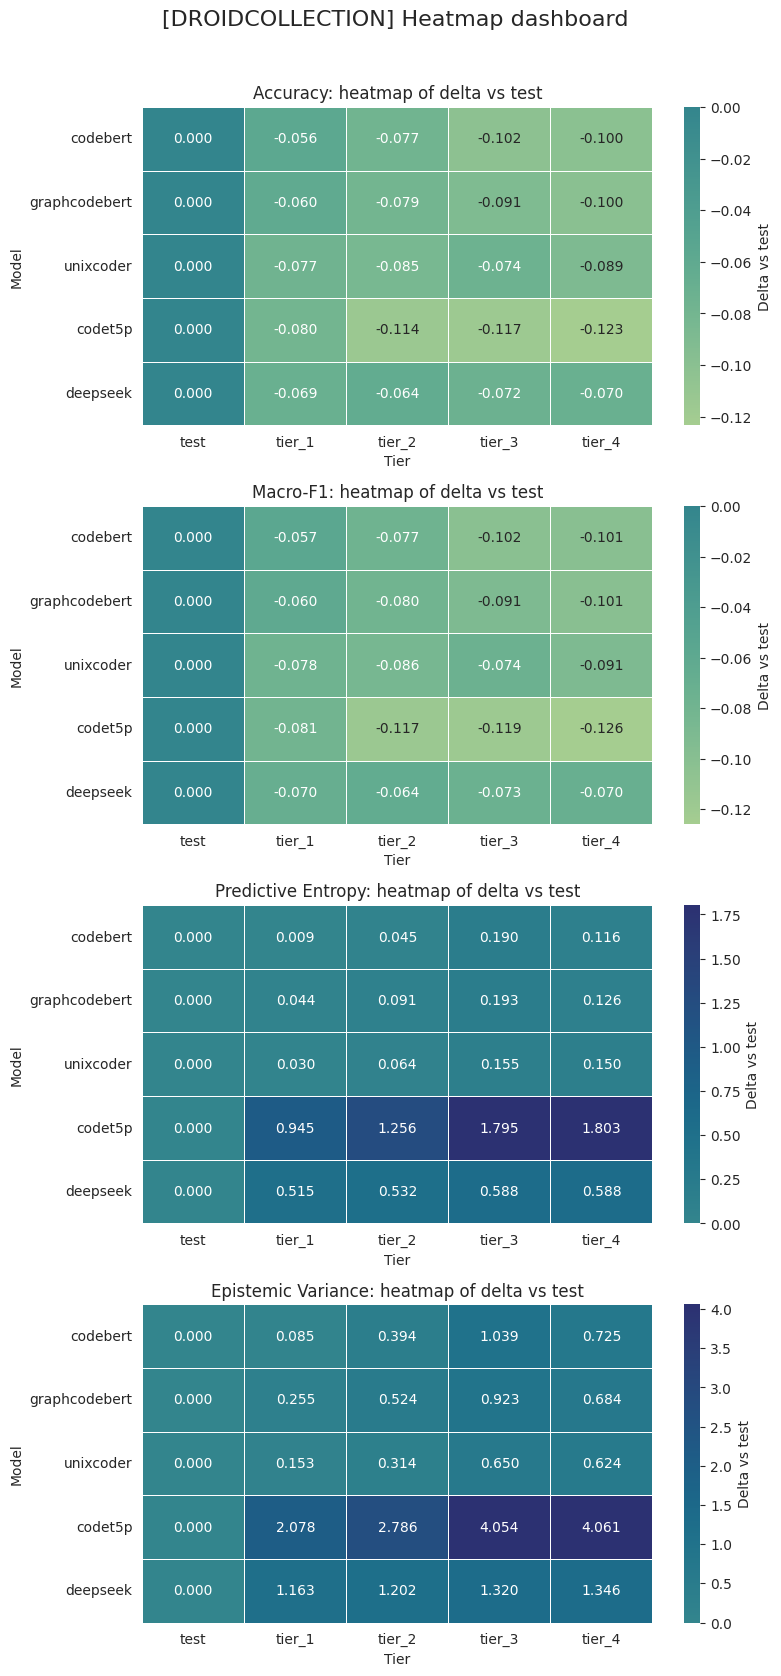

Saved: output/figures/droidcollection_line_dashboard.png
Saved: output/figures/droidcollection_line_dashboard.pdf


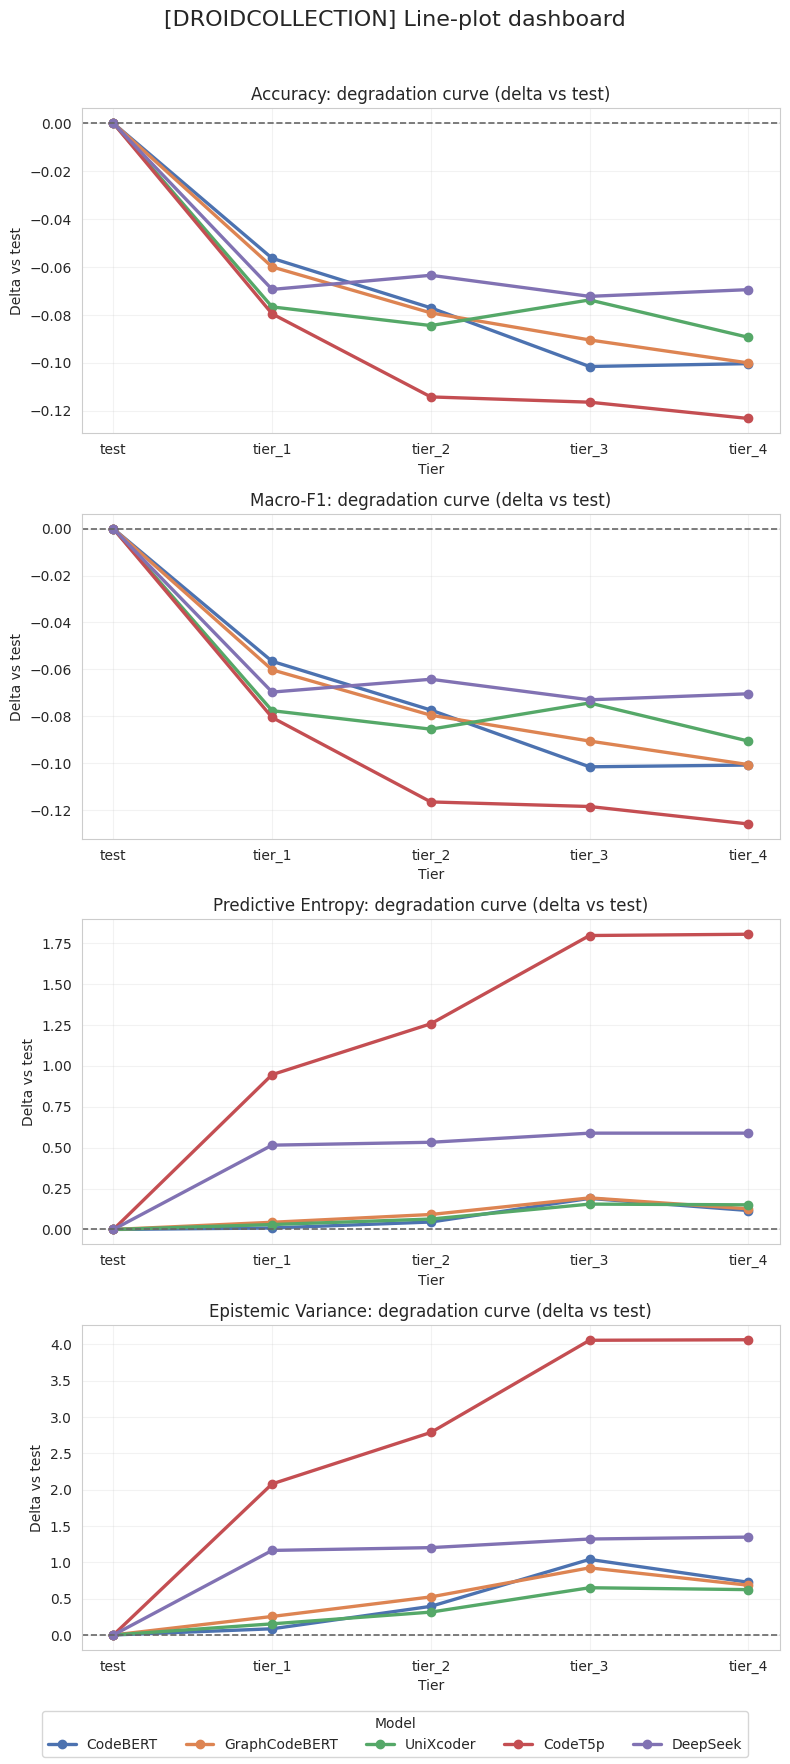

,model_name,tier,accuracy,macro_f1,entropy,epistemic_variance,baseline_accuracy,baseline_macro_f1,baseline_entropy,baseline_epistemic_variance,accuracy_delta,macro_f1_delta,entropy_delta,epistemic_variance_delta
0,codebert,test,0.9848,0.984800,-2.495705,-7.994935,0.9848,0.9848,-2.495705,-7.994935,0.0000,0.000000,0.000000,0.000000
1,codebert,tier_1,0.9284,0.928210,-2.486615,-7.910074,0.9848,0.9848,-2.495705,-7.994935,-0.0564,-0.056590,0.009091,0.084861
2,codebert,tier_2,0.9077,0.907417,-2.450241,-7.601146,0.9848,0.9848,-2.495705,-7.994935,-0.0771,-0.077383,0.045464,0.393789
3,codebert,tier_3,0.8832,0.883188,-2.306054,-6.955460,0.9848,0.9848,-2.495705,-7.994935,-0.1016,-0.101612,0.189651,1.039475
4,codebert,tier_4,0.8844,0.883945,-2.379899,-7.269958,0.9848,0.9848,-2.495705,-7.994935,-0.1004,-0.100855,0.115806,0.724977


In [48]:
from IPython.display import display

metric_titles = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "entropy": "Predictive Entropy",
    "epistemic_variance": "Epistemic Variance",
}

metric_ylabels = {
    "accuracy": "Delta vs test",
    "macro_f1": "Delta vs test",
    "entropy": "Delta vs test",
    "epistemic_variance": "Delta vs test",
}


def pretty_model_name(model_name):
    model_key = str(model_name).lower()
    if "graphcodebert" in model_key:
        return "GraphCodeBERT"
    if "codebert" in model_key and "graph" not in model_key:
        return "CodeBERT"
    if "unixcoder" in model_key:
        return "UniXcoder"
    if "codet5p" in model_key:
        return "CodeT5p"
    if "deepseek" in model_key:
        return "DeepSeek"
    return str(model_name).replace("-", " ").title()


def prepare_eval_slice(slice_df):
    slice_df = slice_df.copy()
    if "true_label" not in slice_df.columns or "pred_label" not in slice_df.columns:
        return pd.DataFrame()

    slice_df = slice_df[slice_df["true_label"] != "true_label"].copy()
    slice_df = slice_df.dropna(subset=["true_label", "pred_label"])
    if slice_df.empty:
        return slice_df

    slice_df["true_label"] = slice_df["true_label"].astype(float).astype(int)
    slice_df["pred_label"] = slice_df["pred_label"].astype(float).astype(int)

    for metric in ["entropy", "epistemic_variance"]:
        if metric in slice_df.columns:
            slice_df[metric] = pd.to_numeric(slice_df[metric], errors="coerce")

    return slice_df


def build_comparison_summary(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    summary_rows = []

    for model in models:
        for tier in tiers:
            slice_df = prepare_eval_slice(df_source[(df_source["model_name"] == model) & (df_source["tier"] == tier)])
            if slice_df.empty:
                continue

            y_true = slice_df["true_label"].to_numpy(dtype=int)
            y_pred = slice_df["pred_label"].to_numpy(dtype=int)

            row = {
                "model_name": model,
                "tier": tier,
                "accuracy": float(np.mean(y_true == y_pred)),
                "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            }

            for metric in ["entropy", "epistemic_variance"]:
                if metric not in slice_df.columns:
                    row[metric] = np.nan
                    continue
                values = slice_df[metric].dropna()
                row[metric] = float(np.median(np.log10(values.to_numpy(dtype=float) + 1e-12))) if not values.empty else np.nan

            summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    if summary_df.empty:
        raise ValueError("No valid rows found for comparison dashboards.")

    baseline = (
        summary_df[summary_df["tier"] == "test"]
        .rename(columns={
            "accuracy": "baseline_accuracy",
            "macro_f1": "baseline_macro_f1",
            "entropy": "baseline_entropy",
            "epistemic_variance": "baseline_epistemic_variance",
        })[["model_name", "baseline_accuracy", "baseline_macro_f1", "baseline_entropy", "baseline_epistemic_variance"]]
    )
    summary_df = summary_df.merge(baseline, on="model_name", how="left")
    summary_df["accuracy_delta"] = summary_df["accuracy"] - summary_df["baseline_accuracy"]
    summary_df["macro_f1_delta"] = summary_df["macro_f1"] - summary_df["baseline_macro_f1"]
    summary_df["entropy_delta"] = summary_df["entropy"] - summary_df["baseline_entropy"]
    summary_df["epistemic_variance_delta"] = summary_df["epistemic_variance"] - summary_df["baseline_epistemic_variance"]

    return summary_df


def plot_heatmap_dashboard(summary_df, metrics, tiers=TIER_ORDER, models=ALL_MODELS, save_name=None):
    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 4.2 * len(metrics)))
    if len(metrics) == 1:
        axes = np.array([axes])

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        pivot_df = (
            summary_df.pivot(index="model_name", columns="tier", values=f"{metric}_delta")
            .reindex(index=models, columns=tiers)
        )
        sns.heatmap(
            pivot_df,
            ax=ax,
            cmap="crest",
            center=0.0,
            annot=True,
            fmt=".3f",
            linewidths=0.5,
            cbar_kws={"label": "Delta vs test"},
        )
        ax.set_title(f"{metric_titles[metric]}: heatmap of delta vs test")
        ax.set_xlabel("Tier")
        ax.set_ylabel("Model")

    fig.suptitle(f"[{DATASET_NAME.upper()}] Heatmap dashboard", fontsize=16, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    if save_name and "save_pub_figure" in globals():
        save_pub_figure(fig, save_name)

    plt.show()
    return fig, axes


def plot_line_dashboard(summary_df, metrics, tiers=TIER_ORDER, models=ALL_MODELS, save_name=None):
    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 4.4 * len(metrics)))
    if len(metrics) == 1:
        axes = np.array([axes])

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        for model in models:
            model_df = summary_df[summary_df["model_name"] == model].set_index("tier").reindex(tiers)
            deltas = model_df[f"{metric}_delta"].dropna()
            if deltas.empty:
                continue
            ax.plot(
                deltas.index,
                deltas.values,
                marker="o",
                linewidth=2.4,
                color=MODEL_COLORS.get(model, "#333333"),
                label=pretty_model_name(model),
            )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ax.set_title(f"{metric_titles[metric]}: degradation curve (delta vs test)")
        ax.set_xlabel("Tier")
        ax.set_ylabel(metric_ylabels[metric])
        ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="Model", loc="lower center", ncol=min(len(labels), 5), frameon=True)
    fig.suptitle(f"[{DATASET_NAME.upper()}] Line-plot dashboard", fontsize=16, y=0.995)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])

    if save_name and "save_pub_figure" in globals():
        save_pub_figure(fig, save_name)

    plt.show()
    return fig, axes


summary_df = build_comparison_summary(df_all)
heatmap_metrics = ["accuracy", "macro_f1", "entropy", "epistemic_variance"]
line_metrics = ["accuracy", "macro_f1", "entropy", "epistemic_variance"]

plot_heatmap_dashboard(summary_df, heatmap_metrics, tiers=TIER_ORDER, models=ALL_MODELS, save_name=f"{DATASET_NAME}_heatmap_dashboard")
plot_line_dashboard(summary_df, line_metrics, tiers=TIER_ORDER, models=ALL_MODELS, save_name=f"{DATASET_NAME}_line_dashboard")

summary_df.head()
